In [1]:
### import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df1=pd.read_csv("Food_Delivery_Times.csv")
df1

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
col=["Distance_km","Preparation_Time_min","Delivery_Time_min"]
S1 = MinMaxScaler()
df1[col]=S1.fit_transform(df1[col])
df1

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,0.378351,Windy,Low,Afternoon,Scooter,0.291667,1.0,0.241379
1,738,0.815979,Clear,Medium,Evening,Bike,0.625000,2.0,0.524138
2,741,0.460309,Foggy,Low,Night,Scooter,0.958333,1.0,0.351724
3,661,0.353093,Rainy,Medium,Afternoon,Scooter,0.000000,1.0,0.200000
4,412,0.950515,Clear,Low,Morning,Bike,0.458333,5.0,0.413793
...,...,...,...,...,...,...,...,...,...
995,107,0.407732,Clear,High,Evening,Car,0.333333,3.0,0.317241
996,271,0.808763,Rainy,Low,Morning,Scooter,0.125000,9.0,0.434483
997,861,0.774742,Snowy,High,Evening,Scooter,0.875000,2.0,0.503448
998,436,0.700000,Clear,Low,Afternoon,Bike,0.125000,0.0,0.324138


In [4]:
X = df1[['Distance_km', 'Preparation_Time_min', 'Traffic_Level', 'Weather']]
Y = df1['Delivery_Time_min'].values

In [6]:
le_traffic = LabelEncoder()
le_weather = LabelEncoder()
X['Traffic_Level'] = le_traffic.fit_transform(X['Traffic_Level'])
X['Weather'] = le_weather.fit_transform(X['Weather'])
X

/var/folders/dz/mssf7jjj0m7g6t776bksdgpc0000gn/T/ipykernel_15083/909375794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Traffic_Level'] = le_traffic.fit_transform(X['Traffic_Level'])
/var/folders/dz/mssf7jjj0m7g6t776bksdgpc0000gn/T/ipykernel_15083/909375794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Weather'] = le_weather.fit_transform(X['Weather'])


,Distance_km,Preparation_Time_min,Traffic_Level,Weather
0,0.378351,0.291667,1,4
1,0.815979,0.625000,2,0
2,0.460309,0.958333,1,1
3,0.353093,0.000000,2,2
4,0.950515,0.458333,1,0
...,...,...,...,...
995,0.407732,0.333333,0,0
996,0.808763,0.125000,1,2
997,0.774742,0.875000,0,3
998,0.700000,0.125000,1,0


In [7]:
 X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=67)

In [8]:
model=LinearRegression()

In [9]:
model.fit(X_train,Y_train)

LinearRegression()

In [10]:
Y_pred = model.predict(X_test)

mse=mean_squared_error(Y_test,Y_pred)
r2=r2_score(Y_test,Y_pred)
print(mse)
print(r2)

0.004821513654557018
0.8039360723107465


In [11]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.06398152933404788
Coefficients: [ 0.39752167  0.16179027 -0.01191861  0.00987536]


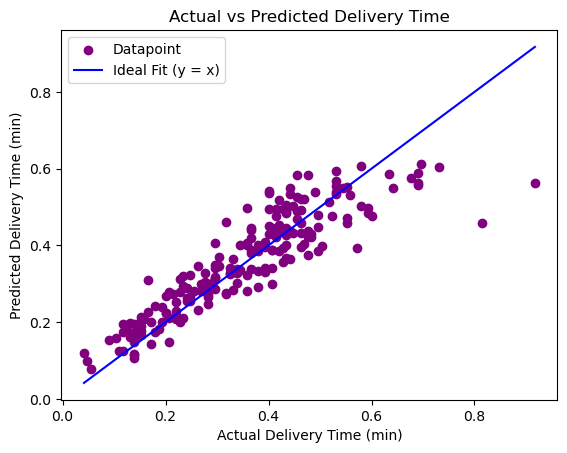

In [12]:
plt.scatter(Y_test, Y_pred, color="purple", label="Datapoint")
# Add diagonal line (perfect prediction line)
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="blue",label="Ideal Fit (y = x)")
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()
plt.show()

In [29]:
df2 = pd.read_csv("Food_Delivery_Times.csv")
X = df2[['Distance_km', 'Preparation_Time_min', 'Traffic_Level', 'Weather']].to_numpy()
Y = df2['Delivery_Time_min'].values

In [30]:
# Encode categorical variables
le_weather = LabelEncoder()
le_traffic = LabelEncoder()
df2['Weather'] = le_weather.fit_transform(df2['Weather'])
df2['Traffic_Level'] = le_traffic.fit_transform(df2['Traffic_Level'])

In [31]:
X = df2[['Distance_km', 'Preparation_Time_min', 'Traffic_Level', 'Weather']].astype(float).values
Y = df2['Delivery_Time_min'].astype(float).values.reshape(-1, 1)

In [32]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
Y = (Y - np.mean(Y)) / np.std(Y)

In [33]:
X = np.hstack((np.ones((X.shape[0], 1)), X))

In [34]:
m = X.shape[0]
learning_rate = 0.01
epochs = 1000
theta = np.zeros((X.shape[1], 1))
MSEH = []

In [35]:
for i in range(epochs):
    Y_pred = np.dot(X, theta)               
    error = Y_pred - Y
    MSE = np.mean(error ** 2)
    MSEH.append(MSE)
    theta = theta - (learning_rate / m) * np.dot(X.T, error)


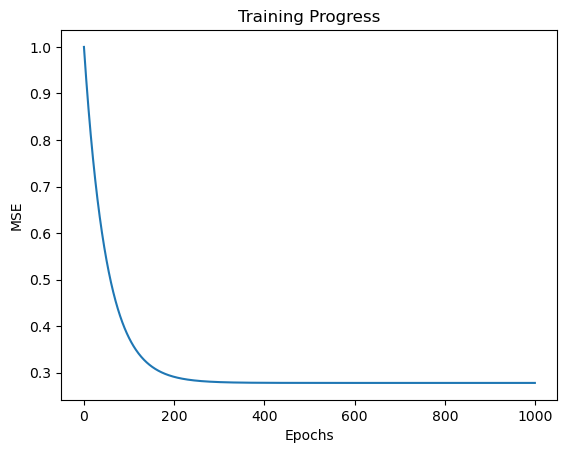

Final Theta:
 [[-1.07869269e-17]
 [ 7.78824210e-01]
 [ 3.18512702e-01]
 [-5.75377993e-02]
 [ 9.78350151e-02]]


In [36]:
plt.plot(MSEH)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Training Progress")
plt.show()

print("Final Theta:\n", theta)